# Setup

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/vols/hyperk/users/sc4422/first_run/WatChMaL')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-116-gd8ae2ac-dirty


# Processing h5 data

In [7]:
cds_geo_path = '/vols/hyperk/WCTE/ML_2025/cds_geometry'

In [8]:
# idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M/emu_ALL.npz"
# test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

idxs_path_new_geo = cds_geo_path + "/split_paths/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu/emu_ALL.npz"
test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

In [9]:
# data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_3M_mu-_3M_0to1GeV_fixedFC_fixedmu_6M.h5"
# h5_file_new_geo = h5py.File(data_path_new_geo, "r")

data_path_new_geo = cds_geo_path + "/h5_files/wcte_CDS_pgun_e-_10M_mu-_10M_0to1GeV_fixedFC_fixed_mu.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

In [10]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [11]:
data_new_geo = get_values(h5_file_new_geo, test_idxs_new_geo)

# Processing fitQun data

In [12]:
def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
    N = len(all_event_ids)
    cut_start_idxs: list[int] = [0]
    CUTOFF = 500
    for i in range(N - 1):
        if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
            cut_start_idxs.append(i+ 1)
    cut_start_idxs.append(len(all_event_ids)-1)
    return cut_start_idxs

def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
    missing_ids_fq = []
    missing_inds_fq = []
    missing_ids_h5 = []    
    missing_inds_h5 = []
    n_cuts = len(fq_cuts)
    assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
    for i in range(1, n_cuts):
        fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
        h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

        fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
        h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

        assert fq_ids[0] < 100
        assert fq_ids[-1] > 990

        missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
        if len(missing_both) > 0:
            print(missing_both)

        missing_fq = np.setdiff1d(fq_ids, h5_ids)
        inds_fq = np.searchsorted(fq_ids, missing_fq)

        missing_ids_fq.append(missing_fq.tolist())
        missing_inds_fq.append(fq_start_idx + inds_fq)


        missing_h5 = np.setdiff1d(h5_ids, fq_ids)
        inds_h5 = np.searchsorted(h5_ids, missing_h5)

        missing_ids_h5.append(missing_h5.tolist())
        missing_inds_h5.append(h5_start_idx + inds_h5)
    
    return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [13]:
# fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_full)

In [14]:
# #Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
# fq_event_ids = fq.chain['nevt'] #.compute()
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo['event_ids']

# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)
# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))

In [15]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo['event_ids'])), missing_indices_h5)

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [16]:
# h5_electron_flag = fq.electron_flag
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
# h5_muon_flag = fq.muon_flag#.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# fc_cut = data_new_geo['fc'][h5_keep_idx]
# mu_cut = data_new_geo['labels'][h5_keep_idx]==2
# el_cut = data_new_geo['labels'][h5_keep_idx]==1

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [17]:
# mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# fq_mu_nll = mu_mu - el_mu
# fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [18]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [19]:
def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = data['towall'] > 100
    nhits_cut = data['nhits'] > 25
    energies_cut = data['energies'] > 800

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo = apply_cuts(data_new_geo)

In [20]:
e_idxs_new_geo = data_new_geo['labels']==1
mu_idxs_new_geo = data_new_geo['labels']==2

In [21]:
def get_particle_quantities(data, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    particle_mask = data['labels'] == particle_type

    labels = data['labels'][particle_mask]
    momentum = data['momentum'][particle_mask]
    positions = data['positions'][particle_mask]
    directions = data['directions'][particle_mask]
    angles = data['angles'][particle_mask]
    dwall = data['dwall'][particle_mask]
    towall = data['towall'][particle_mask]
    cuts_selected = cuts[particle_mask] if cuts is not None else None
    indices = cuts[particle_mask]

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

In [22]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo, 1, cuts_new_geo)
mu_labels, mu_mom, mu_pos, mu_dir, mu_ang, mu_dwall, mu_towall, mu_cuts, mu_idxs = get_particle_quantities(data_new_geo, 2, cuts_new_geo)

# should replace this with the method below / other way around

In [23]:
resnet_args = {'linestyle':"-"}
electron_args_new_geo = {'indices':test_idxs_new_geo[e_idxs_new_geo], 'selection':e_cuts}
muon_args_new_geo = {'indices':test_idxs_new_geo[mu_idxs_new_geo],'selection':mu_cuts}

# Loading ResNet results

In [24]:
outdir_reg = "/vols/hyperk/users/sc4422/first_run/outputs/"

In [25]:

output_resnet = 'regression/electrons/baseline/2026-04-04/14-39-40/'

# ### GNN

output_gnn_1epoch = 'gnn/regression/electrons/2026-04-14/02-57-34-587/'
output_gnn_2epoch = 'gnn/regression/electrons/2026-04-14/05-02-33-158/'
output_gnn_3epoch = 'gnn/regression/electrons/2026-04-14/06-13-02-311/'

# 5 epochs
output_gnn_64hfeat = 'gnn/regression/electrons/hfeat/2026-04-14/07-58-10-343/'
output_gnn_128hfeat = 'gnn/regression/electrons/hfeat/2026-04-14/10-56-23-121/'
output_gnn_lr0_0005_bs_512 = 'gnn/regression/electrons/lr/2026-04-14/12-49-10-397/'
output_gnn_lr0_0007_bs_512 = 'gnn/regression/electrons/lr/2026-04-14/15-03-05-664/'
output_gnn_lr0_001_bs_512 = 'gnn/regression/electrons/lr/2026-04-14/17-16-34-279/'
output_gnn_lr0_001_bs_1024 = 'gnn/regression/electrons/lr/2026-04-14/19-30-32-699/'
output_gnn_lr0_0015_bs_1024 = 'gnn/regression/electrons/lr/2026-04-14/21-26-35-152/'
output_gnn_lr0_002_bs_1024 = 'gnn/regression/electrons/lr/2026-04-14/22-45-59-718/'
output_gnn_withupdates = 'gnn/regression/electrons/2026-04-15/09-16-13-558/'


## wu - with updates + best lr and bs baseline (0.001, 256) - slighlty lower bs for the high hfeat

output_gnn_wu_64hfeat = 'gnn/regression/electrons/hfeat/2026-04-20/02-54-58-697/'
output_gnn_wu_128hfeat = 'gnn/regression/electrons/hfeat/2026-04-20/02-55-02-378/'

## wu lr 0.001 bs 128 hfeate

output_gnn_wu_10knn = 'gnn/regression/electrons/knn/2026-04-20/03-04-05-541/'
output_gnn_wu_20knn = 'gnn/regression/electrons/knn/2026-04-20/08-22-31-058/'
output_gnn_wu_30knn = 'gnn/regression/electrons/knn/2026-04-20/10-00-27-474/'


# gat
output_gat_allpmt = 'gnn/regression/electrons/2026-04-22/11-19-12-335/'
output_gat_hitsonly = 'gnn/regression/electrons/2026-04-22/11-19-36-098/'

# 2026-04-23 multi-head/hfeat runs (excl. 14-59)
# output_heads1_hfeat1 = 'gnn/regression/electrons/2026-04-23/14-41-12-208/'
output_gat_heads2_hfeat128 = 'gnn/regression/electrons/2026-04-23/14-58-39-309/'
output_gat_heads2_hfeat64  = 'gnn/regression/electrons/2026-04-23/15-00-20-857/'
output_gat_heads6_hfeat64  = 'gnn/regression/electrons/2026-04-23/15-01-00-871/'
output_gat_heads6_hfeat32  = 'gnn/regression/electrons/2026-04-23/15-01-39-831/'
output_gat_heads8_hfeat32  = 'gnn/regression/electrons/2026-04-23/15-04-01-707/'
# output_gnn_256hfeat = 'gnn/regression/electrons/hfeat/2026-04-14/12-48-11-024/'

output_gat_v2 = 'gnn/regression/electrons/2026-05-02/12-48-59-995/'
output_gat_edge = 'gnn/regression/electrons/2026-05-06/11-11-17-880/'
output_gat_v2_edge = 'gnn/regression/electrons/2026-05-06/20-52-29-863/'
output_gat_edge_new = 'gnn/regression/electrons/2026-05-06/21-32-24-337/'

output_hgt = 'gnn/regression/electrons/2026-05-07/16-47-28-450/'
output_hgt_no_orientation = 'gnn/regression/electrons/2026-05-08/17-33-14-261/'
output_hgt_no_orientation_2 = 'gnn/regression/electrons/2026-05-08/18-48-25-188'


output_gatv2_lr_0_0005_bs_256 = 'gnn/regression/electrons/lr/2026-05-10/22-38-07-820/'
output_gatv2_lr_0_0007_bs_256 = 'gnn/regression/electrons/lr/2026-05-10/23-50-58-500/'
output_gatv2_lr_0_001_bs_ = 'gnn/regression/electrons/lr/2026-05-10/23-52-03-593/'



output_hgt_1 = "gnn/regression/electrons/2026-05-09/00-03-46-105/"
output_hgt_2 = "gnn/regression/electrons/2026-05-09/00-03-46-572/"
output_hgt_3 = "gnn/regression/electrons/2026-05-09/06-24-49-571/"
output_hgt_4 = "gnn/regression/electrons/2026-05-09/07-52-47-311/"
output_hgt_no_bn = 'gnn/regression/electrons/2026-05-09/17-31-26-268/'
output_hgt_avg_no_bn = 'gnn/regression/electrons/2026-05-09/19-16-31-139/'

output_avg_nobn = 'gnn/regression/electrons/2026-05-10/10-55-20-591/'
output_no_avg_nobn = 'gnn/regression/electrons/2026-05-10/10-57-14-942'
output_avg_bn = 'gnn/regression/electrons/2026-05-10/11-05-04-736/'
output_higher_lr = 'gnn/regression/electrons/2026-05-10/12-55-02-119/'
output_hgt_15epochs = 'gnn/regression/electrons/lr/2026-05-12/10-13-34-811/'

output_lr_0_0007_bs_512 = 'gnn/regression/electrons/lr/2026-05-13/10-34-24-199/'
output_lr_0_0005_bs_256 = 'gnn/regression/electrons/lr/2026-05-14/03-16-30-309/'
output_lr_0_0006_bs_256 = 'gnn/regression/electrons/lr/2026-05-14/12-50-35-339/'
output_lr_0_001_bs_512 = 'gnn/regression/electrons/lr/2026-05-14/12-55-27-335/'

output_coslr = 'gnn/regression/electrons/2026-05-14/17-43-08-499/'
output_use_orient = 'gnn/regression/electrons/2026-05-14/22-14-17-071/'
output_diff_lr_schedl = 'gnn/regression/electrons/2026-05-16/10-18-41-562/'

output_lr_sched_eta_min = 'gnn/regression/electrons/2026-05-17/12-09-53-267/'

output_warm_restarts = 'gnn/regression/electrons/lr/2026-05-21/21-42-06-524/'
output_warm_restarts_0_001_512 = 'gnn/regression/electrons/lr/2026-05-22/10-07-52-309/'
output_warmrestarts_globalpmtpos = 'gnn/regression/electrons/lr/2026-05-23/00-17-50-935'
output_warmrestarts_globalpmtpos_lr = 'gnn/regression/electrons/lr/2026-05-23/11-42-01-137/'


# which have mpmt pmt pooling!!!


output_1 = 'gnn/regression/electrons/2026-05-23/13-20-29-846/'
output_2 = 'gnn/regression/electrons/2026-05-23/18-19-36-393/' # the same as the first successful run but with a scheduler

### Variations of global pos, lr sched - all with updated mlp ( think?), wiht mpmt pmt pooling
output_3 = 'gnn/regression/electrons/2026-05-24/11-58-16-606' # with scalar numbering, no global pos, lr 0.001, no scheduler
output_4 = 'gnn/regression/electrons/2026-05-24/15-10-16-404/' # with no scalar numbering, global pos, lr 0.0015, eta min 1e-5
output_5 = 'gnn/regression/electrons/2026-05-25/00-09-48-919/' # with no scalar numbering, global pos, lr 0.001, eta min 1e-5

# hang on check if they all used adamW
output_6 = 'gnn/regression/electrons/2026-05-25/09-27-44-725/'
output_7 = 'gnn/regression/electrons/2026-05-25/09-31-42-127/'
output_8 = 'gnn/regression/electrons/2026-05-25/09-37-40-408/'
output_9 = 'gnn/regression/electrons/2026-05-25/11-12-26-543/'

output_overfitting_1 = 'gnn/regression/electrons/2026-05-26/16-48-36-318/'
output_overfitting_2 = 'gnn/regression/electrons/2026-05-27/06-43-46-772/'

# # mpmt average + no batch norm 
output_hgt_new_1 = 'gnn/regression/electrons/2026-05-10/10-55-20-591/' 



output_mpmt_within_1 = '/gnn/regression/electrons/2026-05-31/11-16-43-057/'
output_mpmt_within_2 = 'gnn/regression/electrons/2026-05-31/11-26-38-578/'
output_mpmt_within_3 = 'gnn/regression/electrons/2026-05-31/15-39-02-322/'


# resnet_e_position = [
#     WatChMaLPositionRegression(outdir_reg + output_resnet,        "ResNet 50 Position",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_hgt_avg_no_bn, "HGT Baseline Implementation",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt,           "HGT",                 e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_1,         "HGT 1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_2,         "HGT 2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_3,         "HGT 3",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_4,         "HGT 4",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_avg_nobn,     "HGT Avg No BN",           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_no_avg_nobn,   "HGT No Avg No BN",    e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_avg_bn,        "HGT Avg BN",          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_higher_lr,     "HGT Avg BN Higher LR",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_mpmtpmt,   "HGT MPMT+PMT",        e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_new_1,     "HGT mPMT + PMT pooling",            e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_hgt_15epochs,  "HGT mPMT + PMT pooling",            e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_lr_0_0007_bs_512, "LR 0.0007 BS 512",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_lr_0_0005_bs_256, "LR 0.0005 BS 256",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_lr_0_0006_bs_256, "LR 0.0006 BS 256",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_lr_0_001_bs_512,  "LR 0.001 BS 512",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_coslr,  "output_coslr",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_use_orient,  "output_use_orient",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_diff_lr_schedl,  "output_diff_lr_schedl",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_lr_sched_eta_min,  "Cos lr scheduler on baseline",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_warm_restarts,  "output_warm_restarts",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_warm_restarts_0_001_512,  "output_warm_restarts_0_001_512",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_warmrestarts_globalpmtpos,  "Scheduler, pmt global pos",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_warmrestarts_globalpmtpos_lr,  "output_warmrestarts_globalpmtpos_lr",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_2,  "Cos LR with warm restarts scheduler on baseline",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    
# #     WatChMaLPositionRegression(outdir_reg + output_1,  "Cos LR with warm restarts scheduler on baseline (15 epochs)",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_2,  "Cos LR with warm restarts scheduler on baseline",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_3,  "No scheduler, pmt number, no pmt global pos, lr 0.001",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_warmrestarts_globalpmtpos,  "Scheduler, pmt global pos",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_4,  "Scheduler, no pmt number, pmt global pos, lr 0.0015",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_5,  "Scheduler, no pmt number, pmt global pos, lr 0.001",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_6,  "output_6",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_7,  "Scheduler, no pmt number, pmt global pos, lr 0.002",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_8,  "AdamW",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_9,  "Hidden feature reduction",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_overfitting_1,  "output_overfitting_1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_overfitting_2,  "output_overfitting_2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_direction = [
#     WatChMaLDirectionRegression(outdir_reg + output_resnet,        "ResNet50 Direction",  e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_hgt_avg_no_bn, "HGT Baseline Implementation",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt,           "HGT",                 e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_1,         "HGT 1",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_2,         "HGT 2",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_3,         "HGT 3",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_4,         "HGT 4",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_avg_nobn,     "HGT Avg No BN",           e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_no_avg_nobn,   "HGT No Avg No BN",    e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_avg_bn,        "HGT Avg BN",          e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_higher_lr,     "HGT Avg BN Higher LR",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_mpmtpmt,   "HGT MPMT+PMT",        e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_new_1,     "HGT mPMT + PMT pooling",            e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_hgt_15epochs,  "HGT mPMT + PMT pooling",            e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_lr_0_0007_bs_512, "LR 0.0007 BS 512",              e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_lr_0_0005_bs_256, "LR 0.0005 BS 256",              e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_lr_0_0006_bs_256, "LR 0.0006 BS 256",              e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_lr_0_001_bs_512,  "LR 0.001 BS 512",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_coslr,  "output_coslr",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_use_orient,  "output_use_orient",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_diff_lr_schedl,  "output_diff_lr_schedl",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_lr_sched_eta_min,  "Cos lr scheduler on baseline",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_warm_restarts,  "output_warm_restarts",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_warm_restarts_0_001_512,  "output_warm_restarts_0_001_512",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_warmrestarts_globalpmtpos,  "Scheduler, pmt global pos",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_warmrestarts_globalpmtpos_lr,  "output_warmrestarts_globalpmtpos_lr",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_2,  "Cos LR with warm restarts scheduler on baseline",               e_dir, **electron_args_new_geo, **resnet_args),
    
# #     WatChMaLDirectionRegression(outdir_reg + output_1,  "Cos LR with warm restarts scheduler on baseline (15 epochs)",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_warmrestarts_globalpmtpos_lr,  "output_warmrestarts_globalpmtpos_lr",               e_dir, **electron_args_new_geo, **resnet_args),
    
# #     WatChMaLDirectionRegression(outdir_reg + output_warmrestarts_globalpmtpos,  "Scheduler, pmt global pos",               e_dir, **electron_args_new_geo, **resnet_args),
    
# #     WatChMaLDirectionRegression(outdir_reg + output_2,  "Cos LR with warm restarts scheduler on baseline",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_3,  "No scheduler, pmt number, no pmt global pos, lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_4,  "Scheduler, no pmt number, pmt global pos, lr 0.0015",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_5,  "Scheduler, no pmt number, pmt global pos, lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_6,  "Scheduler, no pmt number, pmt global pos, lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_7,  "Scheduler, no pmt number, pmt global pos, lr 0.002",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_8,  "AdamW",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_9,  "Hidden feature reduction",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_overfitting_1,  "output_overfitting_1",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_overfitting_2,  "output_overfitting_2",               e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_energy = [
#     WatChMaLEnergyRegression(outdir_reg + output_resnet,        "ResNet50 Energy",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",    e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_hgt_avg_no_bn, "HGT Baseline Implementation",    e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt,           "HGT",              e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_1,         "HGT 1",            e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_2,         "HGT 2",            e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_3,         "HGT 3",            e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_4,         "HGT 4",            e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_avg_nobn,     "HGT Avg No BN",        e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_no_avg_nobn,   "HGT No Avg No BN", e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_avg_bn,        "HGT Avg BN",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_higher_lr,     "HGT Avg BN Higher LR",    e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_mpmtpmt,   "HGT MPMT+PMT",     e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_new_1,     "HGT MPMT",         e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_hgt_15epochs,  "HGT MPMT",         e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_lr_0_0007_bs_512, "LR 0.0007 BS 512", e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_lr_0_0005_bs_256, "LR 0.0005 BS 256", e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_lr_0_0006_bs_256, "LR 0.0006 BS 256", e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_lr_0_001_bs_512,  "LR 0.001 BS 512",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_coslr,  "output_coslr",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_use_orient,  "output_use_orient",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_diff_lr_schedl,  "output_diff_lr_schedl",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_lr_sched_eta_min,  "Cos lr scheduler on baseline",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_warm_restarts,  "output_warm_restarts",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_warm_restarts_0_001_512,  "output_warm_restarts_0_001_512",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_warmrestarts_globalpmtpos,  "Scheduler, pmt global pos",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_warmrestarts_globalpmtpos_lr,  "output_warmrestarts_globalpmtpos_lr",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_2,  "Cos LR with restarts scheduler on baseline",  e_mom, 1, **electron_args_new_geo, **resnet_args),
    
# #     WatChMaLEnergyRegression(outdir_reg + output_1,  "Cos LR with restarts scheduler on baseline (15 epochs)",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_2,  "Scheduler on baseline",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_warmrestarts_globalpmtpos,  "Scheduler, pmt global pos",  e_mom, 1, **electron_args_new_geo, **resnet_args),
    
# #     WatChMaLEnergyRegression(outdir_reg + output_3,  "No scheduler, pmt number, no pmt global pos, lr 0.001",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_4,  "Scheduler, no pmt number, pmt global pos, lr 0.0015",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_5,  "Scheduler, no pmt number, pmt global pos, lr 0.001",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_6,  "output_6",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_7,  "Scheduler, no pmt number, pmt global pos, lr 0.002",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_8,  "AdamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_9,  "Hidden feature reduction",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_overfitting_1,  "output_overfitting_1",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_overfitting_2,  "output_overfitting_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

In [26]:
output_mpmt_within_1 = '/gnn/regression/electrons/2026-05-31/11-16-43-057/'
output_mpmt_within_2 = 'gnn/regression/electrons/2026-05-31/11-26-38-578/'
output_mpmt_within_3 = 'gnn/regression/electrons/2026-05-31/15-39-02-322/'

hgt_three_1 = 'gnn/regression/electrons/2026-06-05/13-52-53-747/'
hgt_three_2 ='gnn/regression/electrons/2026-06-05/13-58-41-163/'

hgat = 'gnn/regression/electrons/2026-06-05/14-57-10-437/'
hgat_1 = 'gnn/regression/electrons/2026-06-06/01-49-16-440/'

# adam
hgat_base = 'gnn/regression/electrons/2026-06-07/14-57-30-502/'

# adam_w
hgat_base_1 = 'gnn/regression/electrons/2026-06-07/14-57-33-111/'
# 3 epochs
# hgat_base_2 = 'gnn/regression/electrons/2026-06-07/16-10-31-739/'
# hgat_base_3 = 'gnn/regression/electrons/2026-06-07/23-48-12-520/'

# han_1 = 'gnn/regression/electrons/2026-06-10/17-28-00-119/'

han_4layers_adam = 'gnn/regression/electrons/2026-06-11/13-05-18-201/'
han_4layers_adamW = 'gnn/regression/electrons/2026-06-11/14-15-15-582/'


# resnet_e_position = [
#     WatChMaLPositionRegression(outdir_reg + output_resnet,        "ResNet 50 Position",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_hgt_avg_no_bn, "HGT Baseline Implementation",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #    Regression(outdir_reg + output_4,  "Scheduler, no pmt number, pmt global pos, lr 0.0015",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_5,  "Scheduler, no pmt number, pmt global pos, lr 0.001",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_6,  "output_6",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + output_7,  "Scheduler, no pmt number, pmt global pos, lr 0.002",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_8,  "AdamW",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_9,  "Hidden feature reduction",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_overfitting_1,  "output_overfitting_1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_overfitting_2,  "output_overfitting_2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_mpmt_within_1,  "output_mpmt_within_1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_mpmt_within_2,  "output_mpmt_within_2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_mpmt_within_3,  "output_mpmt_within_3",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgt_three_1,  "hgt_three_1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgt_three_2,  "hgt_three_2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgat,  "hgat",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgat_1,  "hgat_1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgat_base,  "hgat_base",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgat_base_1,  "hgat_base_1",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hgat_base_2,  "hgat_base_2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hgat_base_3,  "hgat_base_3",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + han_4layers_adam,  "han_4layers_adam",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + han_4layers_adamW,  "han_4layers_adamW",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_direction = [
#     WatChMaLDirectionRegression(outdir_reg + output_resnet,        "ResNet50 Direction",  e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_hgt_avg_no_bn, "HGT Baseline Implementation",       e_dir, **electron_args_new_geo, **resnet_args),
# #    rectionRegression(outdir_reg + output_4,  "Scheduler, no pmt number, pmt global pos, lr 0.0015",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_5,  "Scheduler, no pmt number, pmt global pos, lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_6,  "Scheduler, no pmt number, pmt global pos, lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + output_7,  "Scheduler, no pmt number, pmt global pos, lr 0.002",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_8,  "AdamW",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_9,  "Hidden feature reduction",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_overfitting_1,  "output_overfitting_1",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_overfitting_2,  "output_overfitting_2",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_mpmt_within_1,  "output_mpmt_within_1",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_mpmt_within_2,  "output_mpmt_within_2",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_mpmt_within_3,  "output_mpmt_within_3",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgt_three_1,  "hgt_three_1",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgt_three_2,  "hgt_three_2",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat,  "hgat",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_1,  "hgat_1",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_base,  "hgat_base",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_base_1,  "hgat_base_1",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hgat_base_2,  "hgat_base_2",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hgat_base_3,  "hgat_base_3",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + han_4layers_adam,  "han_4layers_adam",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + han_4layers_adamW,  "han_4layers_adamW",               e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_energy = [
#     WatChMaLEnergyRegression(outdir_reg + output_resnet,        "ResNet50 Energy",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",    e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_hgt_avg_no_bn, "HGT Baseline Implementation",    e_mom, 1, **electron_args_new_geo, **resnet_args),
# #   ergyRegression(outdir_reg + output_4,  "Scheduler, no pmt number, pmt global pos, lr 0.0015",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_5,  "Scheduler, no pmt number, pmt global pos, lr 0.001",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_6,  "output_6",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + output_7,  "Scheduler, no pmt number, pmt global pos, lr 0.002",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_8,  "AdamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_9,  "Hidden feature reduction",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_overfitting_1,  "output_overfitting_1",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_overfitting_2,  "output_overfitting_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_mpmt_within_1,  "output_mpmt_within_1",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_mpmt_within_2,  "output_mpmt_within_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_mpmt_within_3,  "output_mpmt_within_3",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgt_three_1,  "hgt_three_1",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgt_three_2,  "hgt_three_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat,  "hgat",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_1,  "hgat_1",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_base,  "hgat_base",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_base_1,  "hgat_base_1",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hgat_base_2,  "hgat_base_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hgat_base_3,  "hgat_base_3",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + han_4layers_adam,  "han_4layers_adam",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + han_4layers_adamW,  "han_4layers_adamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]


In [27]:
## HAN



### need to rename your models!!!


output_mpmt_within_1 = '/gnn/regression/electrons/2026-05-31/11-16-43-057/'
output_mpmt_within_2 = 'gnn/regression/electrons/2026-05-31/11-26-38-578/'
output_mpmt_within_3 = 'gnn/regression/electrons/2026-05-31/15-39-02-322/'

hgt_three_1 = 'gnn/regression/electrons/2026-06-05/13-52-53-747/'
hgt_three_2 ='gnn/regression/electrons/2026-06-05/13-58-41-163/'

hgat = 'gnn/regression/electrons/2026-06-05/14-57-10-437/'
hgat_1 = 'gnn/regression/electrons/2026-06-06/01-49-16-440/'

# adam
hgat_base = 'gnn/regression/electrons/2026-06-07/14-57-30-502/'

# adam_w
hgat_base_1 = 'gnn/regression/electrons/2026-06-07/14-57-33-111/'
# 3 epochs



# hgat_base_2 = 'gnn/regression/electrons/2026-06-07/16-10-31-739/'
# hgat_base_3 = 'gnn/regression/electrons/2026-06-07/23-48-12-520/'
# thesea re hetero convol

# 3 layers
han_1 = 'gnn/regression/electrons/2026-06-10/17-28-00-119/'

# 4 layers
han_4layers_adam = 'gnn/regression/electrons/2026-06-11/13-05-18-201/'
han_4layers_adamW = 'gnn/regression/electrons/2026-06-11/14-15-15-582/'

hetero_conv_5layers = 'gnn/regression/muons/2026-06-12/13-40-38-705/'


# change to pmt didnt implement
# hetero_convol = 'gnn/regression/muons/2026-06-12/15-49-44-966/'
# hetero_convol_2 = 'gnn/regression/muons/2026-06-12/16-51-37-881/'


hetgat_np = 'gnn/regression/electrons/2026-06-14/20-09-21-184/'
heteroconv_np_5 = 'gnn/regression/electrons/2026-06-14/20-35-31-374/'


# anything before this that is called hetgat is actually higat


higat_pmt = 'gnn/regression/electrons/2026-06-15/07-17-09-649/'


# resnet_e_position = [
#     WatChMaLPositionRegression(outdir_reg + output_resnet,        "ResNet 50 Position",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hgat_base,  "Baseline Adam",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hgat_base_1,  "Baseline AdamW",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hgat_base_2,  "hgat_base_2",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hgat_base_3,  "hgat_base_3",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + han_1,  "HetGAT 3 layers",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + han_4layers_adam,  "HetGAT 4 layers Adam",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + han_4layers_adamW,  "HetGAT 4 layers AdamW",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hetero_conv_5layers,  "HetGAT 5 layers",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + heteroconv_np_5,  "",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + higat_pmt,  "HiGAT PMT-PMT",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),

# ]

# resnet_e_direction = [
#     WatChMaLDirectionRegression(outdir_reg + output_resnet,        "ResNet50 Direction",  e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_base,  "Baseline Adam",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hgat_base_1,  "Baseline AdamW",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hgat_base_2,  "hgat_base_2",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hgat_base_3,  "hgat_base_3",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + han_1,  "HetGAT 3 layers",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + han_4layers_adam,  "HetGAT 4 layers",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + han_4layers_adamW,  "HetGAT 4 layers AdamW",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hetero_conv_5layers,  "HetGAT 5 layers",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + heteroconv_np_5,  "heteroconv_np_5",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + higat_pmt,  "HiGAT PMT-PMT",               e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_energy = [
#     WatChMaLEnergyRegression(outdir_reg + output_resnet,        "ResNet50 Energy",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",    e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_base,  "Baseline Adam",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hgat_base_1,  "Baseline AdamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hetgat_np,  "HiGAT",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hgat_base_2,  "hgat_base_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hgat_base_3,  "hgat_base_3",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + han_1,  "HetGAT 3 layers",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + han_4layers_adam,  "HetGAT 4 layers",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + han_4layers_adamW,  "HetGAT 4 layers AdamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hetero_conv_5layers,  "HetGAT 5 layers",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hetgat_np,  "HiGAT",  e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + heteroconv_np_5,  "heteroconv_np_5",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + higat_pmt,  "HiGAT PMT-PMT",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
# ]


In [28]:
## HAN



### need to rename your models!!!


output_mpmt_within_1 = '/gnn/regression/electrons/2026-05-31/11-16-43-057/'
output_mpmt_within_2 = 'gnn/regression/electrons/2026-05-31/11-26-38-578/'
output_mpmt_within_3 = 'gnn/regression/electrons/2026-05-31/15-39-02-322/'

hgt_three_1 = 'gnn/regression/electrons/2026-06-05/13-52-53-747/'
hgt_three_2 ='gnn/regression/electrons/2026-06-05/13-58-41-163/'

hgat = 'gnn/regression/electrons/2026-06-05/14-57-10-437/'
hgat_1 = 'gnn/regression/electrons/2026-06-06/01-49-16-440/'

# adam
hgat_base = 'gnn/regression/electrons/2026-06-07/14-57-30-502/'

# adam_w
hgat_base_1 = 'gnn/regression/electrons/2026-06-07/14-57-33-111/'
# 3 epochs



# hgat_base_2 = 'gnn/regression/electrons/2026-06-07/16-10-31-739/'
# hgat_base_3 = 'gnn/regression/electrons/2026-06-07/23-48-12-520/'
# thesea re hetero convol

# 3 layers
han_1 = 'gnn/regression/electrons/2026-06-10/17-28-00-119/'

# 4 layers
han_4layers_adam = 'gnn/regression/electrons/2026-06-11/13-05-18-201/'
han_4layers_adamW = 'gnn/regression/electrons/2026-06-11/14-15-15-582/'

hetero_conv_5layers = 'gnn/regression/muons/2026-06-12/13-40-38-705/'


# change to pmt didnt implement
# hetero_convol = 'gnn/regression/muons/2026-06-12/15-49-44-966/'
# hetero_convol_2 = 'gnn/regression/muons/2026-06-12/16-51-37-881/'


hetgat_np = 'gnn/regression/electrons/2026-06-14/20-09-21-184/'
heteroconv_np_5 = 'gnn/regression/electrons/2026-06-14/20-35-31-374/'


# anything before this that is called hetgat is actually higat


higat_pmt = 'gnn/regression/electrons/2026-06-15/07-17-09-649/'



#####NEW


# i think compare these to the'correct' graph construction to see if its worth the extra time
nonhiergat_old = 'gnn/regression/exploration/electrons/2026-06-16/13-17-50-661/'
hiergat_old = 'gnn/regression/exploration/electrons/2026-06-16/13-18-22-577/'
# nonhiertrans =
hiertrans_old = 'gnn/regression/exploration/electrons/2026-06-16/13-25-51-786/'

hiertrans_scattermean_old = 'gnn/regression/exploration/electrons/2026-06-16/20-17-47-256/'





# restart with correct graph construction

nonhiergat = 'gnn/regression/exploration/electrons/2026-06-18/21-10-53-157/'
hiergat_mean_pmt = 'gnn/regression/exploration/electrons/2026-06-17/11-53-33-088/'
nonhiertrans = 'gnn/regression/exploration/electrons/2026-06-17/11-15-35-034/'
hiertrans_mean_pmt = 'gnn/regression/exploration/electrons/2026-06-18/03-51-25-435/'

hiergat_mean_mpmtpmt = 'gnn/regression/exploration/electrons/2026-06-18/04-29-09-336/'
hiertrans_mean_mpmtpmt = 'gnn/regression/exploration/electrons/2026-06-18/22-05-03-895/'


# node encoder
hiertrans_nodeenc = 'gnn/regression/exploration/electrons/hpc/10-17-29/'
# nonhiergat_nodeenc = 'gnn/regression/exploration/electrons/hpc/10-52-46/'
nonhiergat_nodeenc = 'gnn/regression/exploration/electrons/hpc/2026-06-20/23-56-47/'# corrected num_layers # 2026-06-20/23-56-47/

# node encoder with layer norn
hiertrans_nodeenc_norm = 'gnn/regression/exploration/electrons/hpc/16-09-35/'
nonhiergat_nodeenc_norm = 'gnn/regression/exploration/electrons/hpc/16-29-15/'

# node encoder with layer norm after

hiertrans_nodeenc_layernorm = 'gnn/regression/exploration/electrons/hpc/2026-06-21/00-03-14/' # layer norm inside and after

# virtual nodes
# hiertrans_virtnode = 'gnn/regression/exploration/electrons/2026-06-19/15-09-56-152/'
# nonhiergat_virtnode = 'gnn/regression/exploration/electrons/2026-06-19/14-29-24-622/'

# global pooling strategy

hiertrans_meanpooling = 'gnn/regression/exploration/electrons/2026-06-20/08-20-55-074/'
nonhiergat_meanpooling = 'gnn/regression/exploration/electrons/2026-06-20/08-07-55-715/'

# Corrected scale of virtual node

hiertrans_virtnode_resconn = 'gnn/regression/exploration/electrons/hpc/19-12-54/'
nonhiergat_virtnode = 'gnn/regression/exploration/electrons/2026-06-20/22-17-39-254/'
hiertrans_virtnode_proj = 'gnn/regression/exploration/electrons/hpc/2026-06-21/10-38-40/'

nonhiergat_6 = 'gnn/regression/exploration/electrons/2026-06-21/21-53-27-270/'
nonhiergat_3 = 'gnn/regression/exploration/electrons/2026-06-21/20-08-51-088/'
nonhiergat_5 = 'gnn/regression/exploration/electrons/2026-06-21/20-08-51-809/'



# waiting on 3


resnet_e_position = [
    WatChMaLPositionRegression(outdir_reg + output_resnet,        "ResNet 50 Position",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + hgat_base,  "Baseline",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + heteroconv_np_5,  "",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + higat_pmt,  "HiGAT PMT-PMT",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiergat_old,  "nonhiergat_old",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiergat_old,  "hiergat_old",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_old,  "hiertrans_old",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_scattermean_old,  "hiertrans_scattermean_old",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + nonhiergat,  "nonhiergat",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiergat_mean_pmt,  "hiergat_mean_pmt",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiergat_mean_mpmtpmt,  "hiergat_mean_mpmtpmt",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiertrans,  "nonhiertrans",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + hiertrans_mean_pmt,  "hiertrans_mean_pmt",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_mean_mpmtpmt,  "hiertrans_mean_mpmtpmt",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_nodeenc,  "hiertrans_nodeenc",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiergat_nodeenc,  "nonhiergat_nodeenc",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiergat_nodeenc_norm,  "nonhiergat_nodeenc_norm",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_nodeenc_norm,  "hiertrans_nodeenc_norm",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_nodeenc_layernorm,  "hiertrans_nodeenc_layernorm",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_virtnode,  "hiertrans_virtnode",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + nonhiergat_virtnode,  "nonhiergat_virtnode",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiergat_meanpooling,  "nonhiergat_meanpooling",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_meanpooling,  "hiertrans_meanpooling",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_virtnode_resconn,  "hiertrans_virtnode_resconn",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_virtnode_proj,  "hiertrans_virtnode_proj",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + nonhiergat_6,  "nonhiergat_6",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + nonhiergat_5,  "nonhiergat_5",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + nonhiergat_3,  "nonhiergat_3",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
]

resnet_e_direction = [
    WatChMaLDirectionRegression(outdir_reg + output_resnet,        "ResNet50 Direction",  e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + hgat_base,  "Baseline",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_base_1,  "Baseline AdamW",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_base_2,  "hgat_base_2",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hgat_base_3,  "hgat_base_3",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + han_1,  "HetGAT 3 layers",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + han_4layers_adam,  "HetGAT 4 layers",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + han_4layers_adamW,  "HetGAT 4 layers AdamW",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hetero_conv_5layers,  "HetGAT 5 layers",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hetgat_np,  "HiGAT",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + heteroconv_np_5,  "heteroconv_np_5",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + higat_pmt,  "HiGAT PMT-PMT",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiergat_old,  "nonhiergat_old",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiergat_old,  "hiergat_old",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_old,  "hiertrans_old",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_scattermean_old,  "hiertrans_scattermean_old",               e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + nonhiergat,  "nonhiergat",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiergat_mean_pmt,  "hiergat_mean_pmt",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiergat_mean_mpmtpmt,  "hiergat_mean_mpmtpmt",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiertrans,  "nonhiertrans",               e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + hiertrans_mean_pmt,  "hiertrans_mean_pmt",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_mean_mpmtpmt,  "hiertrans_mean_mpmtpmt",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiergat_nodeenc,  "nonhiergat_nodeenc",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_nodeenc,  "hiertrans_nodeenc",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiergat_nodeenc_norm,  "nonhiergat_nodeenc_norm",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_nodeenc_norm,  "hiertrans_nodeenc_norm",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_nodeenc_layernorm,  "hiertrans_nodeenc_layernorm",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_virtnode,  "hiertrans_virtnode",               e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + nonhiergat_virtnode,  "nonhiergat_virtnode",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiergat_meanpooling,  "nonhiergat_meanpooling",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_meanpooling,  "hiertrans_meanpooling",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_virtnode_resconn,  "hiertrans_virtnode_resconn",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_virtnode_proj,  "hiertrans_virtnode_proj",               e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + nonhiergat_6,  "nonhiergat_6",               e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + nonhiergat_5,  "nonhiergat_5",               e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + nonhiergat_3,  "nonhiergat_3",               e_dir, **electron_args_new_geo, **resnet_args),
]

resnet_e_energy = [
    WatChMaLEnergyRegression(outdir_reg + output_resnet,        "ResNet50 Energy",  e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + output_gat_hitsonly,  "GAT hits only",    e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + hgat_base,  "Baseline",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_base_1,  "Baseline AdamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hetgat_np,  "HiGAT",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_base_2,  "hgat_base_2",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hgat_base_3,  "hgat_base_3",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + han_1,  "HetGAT 3 layers",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + han_4layers_adam,  "HetGAT 4 layers",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + han_4layers_adamW,  "HetGAT 4 layers AdamW",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hetero_conv_5layers,  "HetGAT 5 layers",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hetgat_np,  "HiGAT",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + heteroconv_np_5,  "heteroconv_np_5",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + higat_pmt,  "HiGAT PMT-PMT",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + nonhiergat_old,  "nonhiergat_old",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiergat_old,  "hiergat_old",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_old,  "hiertrans_old",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_scattermean_old,  "hiertrans_scattermean_old",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
    WatChMaLEnergyRegression(outdir_reg + nonhiergat,  "nonhiergat",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiergat_mean_pmt,  "hiergat_mean_pmt",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiergat_mean_mpmtpmt,  "hiergat_mean_mpmtpmt",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + nonhiertrans,  "nonhiertrans",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
    WatChMaLEnergyRegression(outdir_reg + hiertrans_mean_pmt,  "hiertrans_mean_pmt",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_mean_mpmtpmt,  "hiertrans_mean_mpmtpmt",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + nonhiergat_nodeenc,  "nonhiergat_nodeenc",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_nodeenc,  "hiertrans_nodeenc",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + nonhiergat_nodeenc_norm,  "nonhiergat_nodeenc_norm",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_nodeenc_norm,  "hiertrans_nodeenc_norm",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_nodeenc_layernorm,  "hiertrans_nodeenc_layernorm",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_virtnode,  "hiertrans_virtnode",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
    WatChMaLEnergyRegression(outdir_reg + nonhiergat_virtnode,  "nonhiergat_virtnode",  e_mom, 1, **electron_args_new_geo, **resnet_args), 
#     WatChMaLEnergyRegression(outdir_reg + nonhiergat_meanpooling,  "nonhiergat_meanpooling",  e_mom, 1, **electron_args_new_geo, **resnet_args),     
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_meanpooling,  "hiertrans_meanpooling",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_virtnode_resconn,  "hiertrans_virtnode_resconn",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_virtnode_proj,  "hiertrans_virtnode_proj",  e_mom, 1, **electron_args_new_geo, **resnet_args),     
    WatChMaLEnergyRegression(outdir_reg + nonhiergat_6,  "nonhiergat_6",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
    WatChMaLEnergyRegression(outdir_reg + nonhiergat_5,  "nonhiergat_5",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
    WatChMaLEnergyRegression(outdir_reg + nonhiergat_3,  "nonhiergat_3",  e_mom, 1, **electron_args_new_geo, **resnet_args),   
]


/vols/hyperk/users/sc4422/first_run/WatChMaL/watchmal/utils/math.py:95: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(energy**2 - mass**2)


In [29]:
# ### Hyperparameter tuning

# # NON HIER GAT


# Num layers



# LR Batch size
# lr_0_0001_bs_128 = 'gnn/regression/exploration/electrons/2026-06-22/22-24-20-211/'
# lr_0_0001_bs_256 = 'gnn/regression/exploration/electrons/2026-06-22/23-15-05-237/'
# lr_0_0005_bs_256 = 'gnn/regression/exploration/electrons/2026-06-23/04-25-07-088/'
# lr_0_002_bs_128 = nonhiergat_virtnode
nhg_lr_0_0001_bs_256 = 'gnn/regression/exploration/electrons/2026-06-23/10-17-40-089/'
nhg_lr_0_002_bs_256 ='gnn/regression/exploration/electrons/2026-06-23/10-17-42-777/'
nhg_lr_0_001_bs_128 = 'gnn/regression/exploration/electrons/2026-06-23/10-17-44-739/'
nhg_lr_0_0005_bs_128 = 'gnn/regression/exploration/electrons/2026-06-23/10-37-33-155/'
nhg_lr_0_002_bs_128 = nonhiergat_virtnode


nhg_6l = 'gnn/regression/exploration/electrons/2026-06-21/21-53-27-270/'
nhg_3l = 'gnn/regression/exploration/electrons/2026-06-21/20-08-51-088/'
nhg_5l = 'gnn/regression/exploration/electrons/2026-06-21/20-08-51-809/'

# Small architectural changes
nhg_virt_out = 'gnn/regression/exploration/electrons/2026-06-24/10-15-56-233/'
nhg_res_conn = 'gnn/regression/exploration/electrons/2026-06-24/10-44-22-952/'


# Edge features?


# h feat

nhg_h_feat_128 = 'gnn/regression/exploration/electrons/hpc/2026-06-25/00-42-17/'


# HIER TRANS

# Num layers

ht_pmt_1_mpmt_4 = 'gnn/regression/exploration/electrons/2026-06-23/15-28-40-652/'
ht_pmt_2_mpmt_3 = 'gnn/regression/exploration/electrons/2026-06-23/18-13-44-653/'
ht_pmt_2_mpmt_4 = 'gnn/regression/exploration/electrons/2026-06-23/22-37-15-034/'
ht_pmt_1_mpmt_5 = 'gnn/regression/exploration/electrons/2026-06-24/03-54-34-745/'
ht_pmt_1_mpmt_3 = hiertrans_virtnode_proj

# LR

ht_lr0_001 = 'gnn/regression/exploration/electrons/hpc/2026-06-23/11-00-47/'
ht_lr0_0005 = 'gnn/regression/exploration/electrons/hpc/2026-06-23/11-02-50/'
ht_lr0_002 = hiertrans_virtnode_proj

# Architectural 
hit_res_conn = 'gnn/regression/exploration/electrons/2026-06-24/17-31-59-972/'

ht_hfeat128 = 'gnn/regression/exploration/electrons/2026-06-25/00-43-35-064/'
#



### !!!Need to double check all prev results - the resnet 50 baseline was 10 epochs instead of 5 i thnk -  for the report  ull want a correct comparison

# resnet_e_position = [
#     WatChMaLPositionRegression(outdir_reg + output_resnet,           "ResNet 50 Position",    e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_0001_bs_256,  "nhg_lr_0_0001_bs_256",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_002_bs_256,   "nhg_lr_0_002_bs_256",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_001_bs_128,   "nhg_lr_0_001_bs_128",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_0005_bs_128,  "nhg_lr_0_0005_bs_128",  e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_002_bs_128,   "nhg_lr_0_002_bs_128",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_3l,   "nhg_3l",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_5l,   "nhg_5l",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_6l,   "nhg_6l",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_virt_out,   "nhg_virt_out",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_res_conn,   "nhg_res_conn",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_h_feat_128,   "nhg_h_feat_128",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_pmt_1_mpmt_3,        "ht_pmt_1_mpmt_3",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_pmt_1_mpmt_4,        "ht_pmt_1_mpmt_4",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_pmt_1_mpmt_5,        "ht_pmt_1_mpmt_5",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_pmt_2_mpmt_3,        "ht_pmt_2_mpmt_3",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_pmt_2_mpmt_4,        "ht_pmt_2_mpmt_4",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + hit_res_conn,        "hit_res_conn",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_hfeat128,        "ht_hfeat128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_lr0_001,        "ht_lr0_001",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_lr0_0005,        "ht_lr0_0005",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_lr0_002,        "ht_lr0_002",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_direction = [
#     WatChMaLDirectionRegression(outdir_reg + output_resnet,          "ResNet50 Direction",    e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_0001_bs_256, "nhg_lr_0_0001_bs_256",  e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_002_bs_256,  "nhg_lr_0_002_bs_256",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_001_bs_128,  "nhg_lr_0_001_bs_128",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_0005_bs_128, "nhg_lr_0_0005_bs_128",  e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_002_bs_128,  "nhg_lr_0_002_bs_128",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_3l,  "nhg_3l",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_5l,  "nhg_5l",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_6l,  "nhg_6l",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_virt_out,  "nhg_virt_out",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_res_conn,  "nhg_res_conn",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_h_feat_128,  "nhg_h_feat_128",   e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_pmt_1_mpmt_3,       "ht_pmt_1_mpmt_3",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_pmt_1_mpmt_4,       "ht_pmt_1_mpmt_4",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_pmt_1_mpmt_5,       "ht_pmt_1_mpmt_5",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_pmt_2_mpmt_3,       "ht_pmt_2_mpmt_3",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_pmt_2_mpmt_4,       "ht_pmt_2_mpmt_4",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + hit_res_conn,       "hit_res_conn",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_hfeat128,       "ht_hfeat128",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_lr0_001,       "ht_lr0_001",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_lr0_0005,       "ht_lr0_0005",       e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + ht_lr0_002,       "ht_lr0_002",       e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_energy = [
#     WatChMaLEnergyRegression(outdir_reg + output_resnet,            "ResNet50 Energy",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_0001_bs_256,   "nhg_lr_0_0001_bs_256",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_002_bs_256,    "nhg_lr_0_002_bs_256",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_001_bs_128,    "nhg_lr_0_001_bs_128",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_0005_bs_128,   "nhg_lr_0_0005_bs_128",  e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_002_bs_128,    "nhg_lr_0_002_bs_128",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_3l,    "nhg_3l",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_5l,    "nhg_5l",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_6l,    "nhg_6l",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_virt_out,    "nhg_virt_out",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_res_conn,    "nhg_res_conn",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_h_feat_128,    "nhg_h_feat_128",   e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_pmt_1_mpmt_3,         "ht_pmt_1_mpmt_3",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_pmt_1_mpmt_4,         "ht_pmt_1_mpmt_4",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_pmt_1_mpmt_5,         "ht_pmt_1_mpmt_5",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_pmt_2_mpmt_3,         "ht_pmt_2_mpmt_3",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_pmt_2_mpmt_4,         "ht_pmt_2_mpmt_4",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + hit_res_conn,         "hit_res_conn",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_hfeat128,         "ht_hfeat128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_lr0_001,         "ht_lr0_001",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_lr0_0005,         "ht_lr0_0005",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + ht_lr0_002,         "ht_lr0_002",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

In [30]:
### 10 epoch hyperparameter tuning


# should move them into gnn_exploration

### Hiertrans

output_resnet = '/vols/hyperk/users/sc4422/first_run/new_data/baseline/electrons/2026-06-26/01-57-40/' 
# output_resnet = '/vols/hyperk/users/sc4422/first_run/new_data/baseline/electrons

ht_mpmt_layer_3 = 'gnn/regression/exploration/electrons/2026-06-25/20-46-07-898/'
ht_mpmt_layer_4 = 'gnn/regression/exploration/electrons/2026-06-25/20-46-07-146/'
ht_mpmt_layer_5 = 'gnn/regression/exploration/electrons/2026-06-25/21-03-47-523/'

ht_resconn = 'canada/2026-06-25/12-51-36/' # canada_ 12-51-36/outputs/

ht_h_feat_128 = 'gnn/regression/exploration/electrons/2026-06-28/15-14-03-648/' #'canada/2026-06-25/23-42-40/' # canada_ 2026-06-25/23-42-40/ still running
ht_h_feat_256 = 'canada/2026-06-25/23-49-11/' # 2026-06-25/23-49-11/

ht_etamin_0_00001 = 'canada/2026-06-25/23-49-13/' # canada_ 2026-06-25/23-49-13/ still running


### Non hier gat

# these were all done with the wrong thing 

nhg_layer_4 =  'gnn/regression/exploration/electrons/2026-06-27/15-38-14-823/'
nhg_layer_5 = 'gnn/regression/exploration/electrons/2026-06-27/15-38-10-085/'
nhg_layer_6 = 'gnn/regression/exploration/electrons/2026-06-27/15-38-10-105/'

nhg_h_feat_128 = 'gnn/regression/exploration/electrons/2026-06-27/15-38-51-525/' #2026-06-26/04-30-04/
# nhg_h_feat_256 = #  2026-06-26/04-33-21/.

# nhg_etamin_0_00001 = #2026-06-26/04-33-20/

nhg_lr_0_001 = 'gnn/regression/exploration/electrons/2026-06-27/18-12-04-410/' #2026-06-26/04-45-58/

nhg_etamin_0_007 = 'gnn/regression/exploration/electrons/2026-06-27/17-15-51-657/'

# only resconn had the right T_0

nhg_resconn = 'canada/2026-06-25/23-55-31/'


# resnet_e_position = [
#     WatChMaLPositionRegression(output_resnet,           "ResNet 50 Position",    e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_mpmt_layer_3,        "ht_mpmt_layer_3",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_mpmt_layer_4,        "ht_mpmt_layer_4",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_mpmt_layer_5,        "ht_mpmt_layer_5",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_resconn,        "ht_resconn",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_h_feat_128,        "ht_h_feat_128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_h_feat_256,        "ht_h_feat_256",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_etamin_0_00001,        "ht_etamin_0_00001",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_direction = [
#     WatChMaLDirectionRegression(output_resnet,          "ResNet50 Direction",    e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_mpmt_layer_3,       "ht_mpmt_layer_3",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_mpmt_layer_4,       "ht_mpmt_layer_4",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_mpmt_layer_5,       "ht_mpmt_layer_5",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_resconn,       "ht_resconn",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_h_feat_128,       "ht_h_feat_128",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_h_feat_256,       "ht_h_feat_256",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + ht_etamin_0_00001,       "ht_etamin_0_00001",       e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_energy = [
#     WatChMaLEnergyRegression(output_resnet,            "ResNet50 Energy",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_mpmt_layer_3,         "ht_mpmt_layer_3",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_mpmt_layer_4,         "ht_mpmt_layer_4",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_mpmt_layer_5,         "ht_mpmt_layer_5",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_resconn,         "ht_resconn",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_h_feat_128,         "ht_h_feat_128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_h_feat_256,         "ht_h_feat_256",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + ht_etamin_0_00001,         "ht_etamin_0_00001",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_position = [
#     WatChMaLPositionRegression(output_resnet,                        "ResNet 50 Position",    e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_4,             "nhg_layer_4",           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_5,             "nhg_layer_5",           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_6,             "nhg_layer_6",           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_h_feat_128,          "nhg_h_feat_128",        e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_001,            "nhg_lr_0_001",          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_etamin_0_007,        "nhg_etamin_0_007",      e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_resconn,        "nhg_resconn",      e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_direction = [
#     WatChMaLDirectionRegression(output_resnet,                       "ResNet50 Direction",    e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_layer_4,            "nhg_layer_4",           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_layer_5,            "nhg_layer_5",           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_layer_6,            "nhg_layer_6",           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_h_feat_128,         "nhg_h_feat_128",        e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_001,           "nhg_lr_0_001",          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_etamin_0_007,       "nhg_etamin_0_007",      e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_resconn,       "nhg_resconn",      e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_energy = [
#     WatChMaLEnergyRegression(output_resnet,                          "ResNet50 Energy",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_layer_4,               "nhg_layer_4",           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_layer_5,               "nhg_layer_5",           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_layer_6,               "nhg_layer_6",           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_h_feat_128,            "nhg_h_feat_128",        e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_001,              "nhg_lr_0_001",          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_etamin_0_007,          "nhg_etamin_0_007",      e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_resconn,          "nhg_resconn",      e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]



# noresconn_5mpmtl = 'gnn/regression/exploration/electrons/2026-06-27/16-08-16-227/' # not needed bc its not a combo



In [31]:
### HIer trans


output_resnet = new_data/baseline/electrons/2026-07-04/21-53-10/
## include all the individuals as well in the results
resconn_5mpmtl = 'gnn/regression/exploration/electrons/2026-06-27/16-05-54-644/'
resconn_5mpmtl_hfeat_128 = 'gnn/regression/exploration/electrons/2026-06-29/14-54-30-831/' 
mpmtl5_hfeat_128 = 'gnn/regression/exploration/electrons/2026-06-28/15-47-05-547/'
resconn_hfeat128 = 'gnn/regression/exploration/electrons/2026-06-29/15-01-46-172/' 

resnet_e_position = [
    WatChMaLPositionRegression(output_resnet,           "ResNet 50 Position",    e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_mpmt_layer_3,        "Baseline config",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_mpmt_layer_5,        "5 mpmt layers",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_resconn,        "Res conn",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_h_feat_128,        "Hfeat 128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + resconn_5mpmtl,        "Res conn + 5 mpmt layers",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + resconn_hfeat128,        "Res conn + hfeat 128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + mpmtl5_hfeat_128,        "5 mpmt layers + hfeat 128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + resconn_5mpmtl_hfeat_128,        "5 mpmt layers + hfeat 128 + res conn",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
]
resnet_e_direction = [
    WatChMaLDirectionRegression(output_resnet,          "ResNet50 Direction",    e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + ht_mpmt_layer_3,       "ht_mpmt_layer_3",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + ht_mpmt_layer_5,       "ht_mpmt_layer_5",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + ht_resconn,       "ht_resconn",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + ht_h_feat_128,       "ht_h_feat_128",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl,       "Res conn + 5 mpmt layers",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,       "Res conn + hfeat 128",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + mpmtl5_hfeat_128,       "5 mpmt layers + hfeat 128",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl_hfeat_128,       "5 mpmt layers + hfeat 128 + res conn",       e_dir, **electron_args_new_geo, **resnet_args),
]
resnet_e_energy = [
    WatChMaLEnergyRegression(output_resnet,            "ResNet50 Energy",       e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + ht_mpmt_layer_3,         "ht_mpmt_layer_3",       e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + ht_mpmt_layer_5,         "ht_mpmt_layer_5",       e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + ht_resconn,         "ht_resconn",       e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + ht_h_feat_128,         "ht_h_feat_128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl,       "Res conn + 5 mpmt layers",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,       "Res conn + hfeat 128",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + mpmtl5_hfeat_128,       "5 mpmt layers + hfeat 128",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + resconn_5mpmtl_hfeat_128,         "5 mpmt layers + hfeat 128 + res conn",       e_mom, 1, **electron_args_new_geo, **resnet_args),
]



### non hier gat

## include all the individuals as well
resconn_lr0_001 = 'gnn/regression/exploration/electrons/2026-06-29/15-04-28-989/'
resconn_lr0_001_5layers = 'gnn/regression/exploration/electrons/2026-06-29/15-04-28-931/'
resconn_lr0_001_hfeat128 = 'gnn/regression/exploration/electrons/2026-06-29/15-14-45-875/'
resconn_lr0_001_hfeat128_5layers = # 3168188.pbs-7   sc4422   v1_gpu72 nonhiergat    --    1   6  256gb 60:00 Q   -- 
resconn_hfeat128 = 'gnn/regression/exploration/electrons/2026-07-01/01-18-30-420/' # 4505829.0
resconn_hfeat128_5layers = 'gnn/regression/exploration/electrons/2026-06-29/21-04-48-070/'
resconn_5layers = 'gnn/regression/exploration/electrons/2026-06-29/21-36-52-386/'# sc4422 ID: 4505640   6/29 21:06      _      _      1      1 4505640.0

lr0_001_5layers = 'canada/2026-06-29/14-26-31/' # 46235896   sc4422 rpp-blairt2k     nonhiergat  PD 2-02:00:00     1    6 gres/gpu:h    256G  (None) ## 2026-06-29/14-26-31/
lr0_001_5layers_hfeat128 = # 2026-07-02/06-10-01/ - 46650270   sc4422 rpp-blairt2k     nonhiergat   R 4-23:57:39     1    6 gres/gpu:h    256G fc10606 (None)
lr0_001_hfeat128 = 'canada/2026-06-29/14-30-38/' # 46235984   sc4422 rpp-blairt2k     nonhiergat  PD 2-02:00:00     1    6 gres/gpu:h    256G  (None) ## 2026-06-29/14-30-38/
layers5_hfeat128 = # /2026-06-30/14-37-52/ on  canada 

# maybe record time taken too
# seems a bit random bc the one with three ran gaster than the two indivs? and why are the 5s quicker than my fours

# resnet_e_position = [
#     WatChMaLPositionRegression(output_resnet,                                    "ResNet 50 Position",                            e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_4,                     "baseline",                           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_5,                     "5 layers",                           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_resconn,                     "Res conn",                           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_lr_0_001,                     "+ lr 0.001",                           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001,                     "Res conn + lr 0.001",                           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_5layers,             "Res conn + 5 layers + lr 0.001",           e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_hfeat128,            "Res conn + hfeat 128 + lr 0.001",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers,    "Res conn + hfeat 128 + 5 layers + lr 0.001", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128,                   "Res conn + hfeat 128",                          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128_5layers,           "Res conn + hfeat 128 + 5 layers",          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_5layers,                    "Res conn + 5 layers",                      e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_5layers,                    "5 layers + lr 0.001",                      e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_hfeat128,                   "Hfeat 128 + lr 0.001",                          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + lr0_001_5layers_hfeat128,           "Hfeat 128 + 5 layers + lr 0.001",          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + layers5_hfeat128,                   "Hfeat 128 + 5 layers",                     e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_direction = [
#     WatChMaLDirectionRegression(output_resnet,                                 "ResNet50 Direction",                            e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_layer_4,                  'baseline',                           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_layer_5,                  "5 layers",                           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_resconn,                  "Res conn",                           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nhg_lr_0_001,                  "+ lr 0.001",                           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001,                  "Res conn + lr 0.001",                           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_5layers,          "Res conn + 5 layers + lr 0.001",           e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_hfeat128,         "Res conn + hfeat 128 + lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers, "Res conn + hfeat 128 + 5 layers + lr 0.001", e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,                "Res conn + hfeat 128",                          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128_5layers,        "Res conn + hfeat 128 + 5 layers",          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_5layers,                 "Res conn + 5 layers",                      e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_5layers,                 "5 layers + lr 0.001",                      e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_hfeat128,                "Hfeat 128 + lr 0.001",                          e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + lr0_001_5layers_hfeat128,        "Hfeat 128 + 5 layers + lr 0.001",          e_dir, **electron_args_new_geo, **resnet_args),
# #     WatChMaLDirectionRegression(outdir_reg + layers5_hfeat128,                "Hfeat 128 + 5 layers",                     e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_energy = [
#     WatChMaLEnergyRegression(output_resnet,                                 "ResNet50 Energy",                               e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_layer_4,                  "baseline",                           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_layer_5,                  "5 layers",                           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_resconn,                  "Res conn",                           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nhg_lr_0_001,                  "+ lr 0.001",                           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001,                  "Res conn + lr 0.001",                           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_5layers,          "Res conn + 5 layers + lr 0.001",           e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_hfeat128,         "Res conn + hfeat 128 + lr 0.001",               e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers, "Res conn + hfeat 128 + 5 layers + lr 0.001", e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128,                "Res conn + hfeat 128",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128_5layers,        "Res conn + hfeat 128 + 5 layers",          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_5layers,                 "Res conn + 5 layers",                      e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_5layers,                 "5 layers + lr 0.001",                      e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_hfeat128,                "Hfeat 128 + lr 0.001",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + lr0_001_5layers_hfeat128,                "Hfeat 128 + 5 layers + lr 0.001",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
# #     WatChMaLEnergyRegression(outdir_reg + layers5_hfeat128,                "Hfeat 128 + 5 layers",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (914663885.py, line 4)

In [ ]:
### 15 epochs rerun

# resnet_15epochs = '/vols/hyperk/users/sc4422/first_run//new_data/baseline/electrons/2026-07-03/21-14-41/' # 4513003. hep

resnet_15epochs = '/vols/hyperk/users/sc4422/first_run/new_data/baseline/electrons/2026-07-04/21-53-11/'


## record time for each as well

# Hiertrans

# resconn = 
# mpmtl5 = 
# hfeat128 =  
resconn_5mpmtl = 'gnn/regression/exploration/electrons/2026-07-02/14-50-10-725/'
resconn_5mpmtl_hfeat_128 = 'gnn/regression/exploration/electrons/2026-07-02/14-48-10-283/'
mpmtl5_hfeat_128 = 'gnn/regression/exploration/electrons/2026-07-02/14-53-05-437/'
resconn_hfeat128 = 'gnn/regression/exploration/electrons/2026-07-02/14-48-10-281/'



# resnet_e_position = [
#     WatChMaLPositionRegression(resnet_15epochs,           "ResNet 50 Position",    e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_5mpmtl,        "resconn_5mpmtl",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + mpmtl5_hfeat_128,        "mpmtl5_hfeat_128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128,        "resconn_hfeat128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_5mpmtl_hfeat_128,        "resconn_5mpmtl_hfeat_128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_direction = [
#     WatChMaLDirectionRegression(resnet_15epochs,          "ResNet50 Direction",    e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl,       "resconn_5mpmtl",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + mpmtl5_hfeat_128,       "mpmtl5_hfeat_128",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,       "resconn_hfeat128",       e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl_hfeat_128,       "resconn_5mpmtl_hfeat_128",       e_dir, **electron_args_new_geo, **resnet_args),
# ]
# resnet_e_energy = [
#     WatChMaLEnergyRegression(resnet_15epochs,            "ResNet50 Energy",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_5mpmtl,         "resconn_5mpmtl",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + mpmtl5_hfeat_128,         "mpmtl5_hfeat_128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128,         "resconn_hfeat128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_5mpmtl_hfeat_128,         "resconn_5mpmtl_hfeat_128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

resnet_e_position = [
    WatChMaLPositionRegression(resnet_15epochs,                        "ResNet 50 Position",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + resconn_5mpmtl,            "Res conn + 5 mpmt layers",        e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + mpmtl5_hfeat_128,          "5 mpmt layers + hfeat 128",       e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + resconn_hfeat128,          "Res conn + hfeat 128",            e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(outdir_reg + resconn_5mpmtl_hfeat_128,  "Res conn + 5 mpmt layers + hfeat 128", e_pos, e_dir, **electron_args_new_geo, **resnet_args),
]
resnet_e_direction = [
    WatChMaLDirectionRegression(resnet_15epochs,                       "ResNet50 Direction",              e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl,           "Res conn + 5 mpmt layers",        e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + mpmtl5_hfeat_128,         "5 mpmt layers + hfeat 128",       e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,         "Res conn + hfeat 128",            e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(outdir_reg + resconn_5mpmtl_hfeat_128, "Res conn + 5 mpmt layers + hfeat 128", e_dir, **electron_args_new_geo, **resnet_args),
]
resnet_e_energy = [
    WatChMaLEnergyRegression(resnet_15epochs,                          "ResNet50 Energy",                 e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + resconn_5mpmtl,              "Res conn + 5 mpmt layers",        e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + mpmtl5_hfeat_128,            "5 mpmt layers + hfeat 128",       e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128,            "Res conn + hfeat 128",            e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(outdir_reg + resconn_5mpmtl_hfeat_128,    "Res conn + 5 mpmt layers + hfeat 128", e_mom, 1, **electron_args_new_geo, **resnet_args),
]


# non hiergat

# resconn = 
# lr0_001 = 
# layers5 = 
# hfeat128 =  
resconn_lr0_001 = 'hpc/2026-07-02/2026-07-02/19-06-37/' # 3166635.pbs-7   sc4422   v1_gpu72 nonhiergat    --    1   6  256gb 70:00 Q   -- 
resconn_lr0_001_5layers = 'hpc/2026-07-02/2026-07-02/19-27-22/' # 3166638.pbs-7   sc4422   v1_gpu72 nonhiergat    --    1   6  256gb 70:00 Q   -- 
resconn_lr0_001_hfeat128 = 'hpc/2026-07-02/2026-07-02/18-49-03/' # 3166634.pbs-7   sc4422   v1_gpu72 nonhiergat    --    1   6  256gb 70:00 Q   -- 
resconn_lr0_001_hfeat128_5layers = 'hpc/2026-07-02/2026-07-02/18-33-31/' # 3166633.pbs-7   sc4422   v1_gpu72 nonhiergat    --    1   6  256gb 70:00 Q   -- 
resconn_hfeat128 = 'gnn/regression/exploration/electrons/2026-07-02/15-16-13-042/'
resconn_hfeat128_5layers = 'gnn/regression/exploration/electrons/2026-07-03/12-46-35-148/' # sc4422 ID: 4512846   7/2  15:15      _      _      2      2 4512846.1
resconn_5layers = 'hpc/2026-07-02/2026-07-02/21-16-08/' # 3166641.pbs-7   sc4422   v1_gpu72 nonhiergat    --    1   6  256gb 70:00 Q   --
lr0_001_5layers = 'gnn/regression/exploration/electrons/2026-07-02/15-11-49-185/'
lr0_001_5layers_hfeat128 = 'gnn/regression/exploration/electrons/2026-07-02/15-08-49-783/'
lr0_001_hfeat128 = 'gnn/regression/exploration/electrons/2026-07-02/15-08-46-326/'
layers5_hfeat128 = 'gnn/regression/exploration/electrons/2026-07-02/15-10-30-834/'

# resnet_e_position = [
#     WatChMaLPositionRegression(resnet_15epochs,                                          "ResNet 50 Position",                                e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001,                           "Res conn + lr 0.001",                               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_5layers,                   "Res conn + 5 mpmt layers + lr 0.001",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_hfeat128,                  "Res conn + hfeat 128 + lr 0.001",                   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers,          "Res conn + hfeat 128 + 5 mpmt layers + lr 0.001",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128,                          "Res conn + hfeat 128",                              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128_5layers,                  "Res conn + hfeat 128 + 5 mpmt layers",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_5layers,                           "Res conn + 5 mpmt layers",                          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_5layers,                           "5 mpmt layers + lr 0.001",                          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_5layers_hfeat128,                  "hfeat 128 + 5 mpmt layers + lr 0.001",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_hfeat128,                          "hfeat 128 + lr 0.001",                              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + layers5_hfeat128,                          "hfeat 128 + 5 mpmt layers",                         e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_direction = [
#     WatChMaLDirectionRegression(output_resnet,                                         "ResNet50 Direction",                                e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001,                          "Res conn + lr 0.001",                               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_5layers,                  "Res conn + 5 mpmt layers + lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_hfeat128,                 "Res conn + hfeat 128 + lr 0.001",                   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers,         "Res conn + hfeat 128 + 5 mpmt layers + lr 0.001",   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,                         "Res conn + hfeat 128",                              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128_5layers,                 "Res conn + hfeat 128 + 5 mpmt layers",              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_5layers,                          "Res conn + 5 mpmt layers",                          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_5layers,                          "5 mpmt layers + lr 0.001",                          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_5layers_hfeat128,                 "hfeat 128 + 5 mpmt layers + lr 0.001",              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_hfeat128,                         "hfeat 128 + lr 0.001",                              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + layers5_hfeat128,                         "hfeat 128 + 5 mpmt layers",                         e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_energy = [
#     WatChMaLEnergyRegression(resnet_15epochs,                                            "ResNet50 Energy",                                   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001,                             "Res conn + lr 0.001",                               e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_5layers,                     "Res conn + 5 mpmt layers + lr 0.001",               e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_hfeat128,                    "Res conn + hfeat 128 + lr 0.001",                   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers,            "Res conn + hfeat 128 + 5 mpmt layers + lr 0.001",   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128,                            "Res conn + hfeat 128",                              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128_5layers,                    "Res conn + hfeat 128 + 5 mpmt layers",              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_5layers,                             "Res conn + 5 mpmt layers",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_5layers,                             "5 mpmt layers + lr 0.001",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_5layers_hfeat128,                    "hfeat 128 + 5 mpmt layers + lr 0.001",              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_hfeat128,                            "hfeat 128 + lr 0.001",                              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + layers5_hfeat128,                            "hfeat 128 + 5 mpmt layers",                         e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_position = [
#     # Baseline
#     WatChMaLPositionRegression(resnet_15epochs,                                 "ResNet 50 Position",                                e_pos, e_dir, **electron_args_new_geo, **resnet_args),

#     # Two-factor combinations
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001,                    "Res conn + lr 0.001",                               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128,                   "Res conn + hfeat 128",                              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_5layers,                    "Res conn + 5 mpmt layers",                          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_5layers,                    "5 mpmt layers + lr 0.001",                          e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_hfeat128,                   "hfeat 128 + lr 0.001",                              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + layers5_hfeat128,                   "hfeat 128 + 5 mpmt layers",                         e_pos, e_dir, **electron_args_new_geo, **resnet_args),

#     # Three-factor combinations
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_5layers,            "Res conn + 5 mpmt layers + lr 0.001",               e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_hfeat128,           "Res conn + hfeat 128 + lr 0.001",                   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + resconn_hfeat128_5layers,           "Res conn + hfeat 128 + 5 mpmt layers",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + lr0_001_5layers_hfeat128,           "hfeat 128 + 5 mpmt layers + lr 0.001",              e_pos, e_dir, **electron_args_new_geo, **resnet_args),

#     # Four-factor (full) combination
#     WatChMaLPositionRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers,   "Res conn + hfeat 128 + 5 mpmt layers + lr 0.001",   e_pos, e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_direction = [
#     # Baseline
#     WatChMaLDirectionRegression(output_resnet,                                 "ResNet50 Direction",                                e_dir, **electron_args_new_geo, **resnet_args),

#     # Two-factor combinations
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001,                  "Res conn + lr 0.001",                               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128,                 "Res conn + hfeat 128",                              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_5layers,                  "Res conn + 5 mpmt layers",                          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_5layers,                  "5 mpmt layers + lr 0.001",                          e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_hfeat128,                 "hfeat 128 + lr 0.001",                              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + layers5_hfeat128,                 "hfeat 128 + 5 mpmt layers",                         e_dir, **electron_args_new_geo, **resnet_args),

#     # Three-factor combinations
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_5layers,          "Res conn + 5 mpmt layers + lr 0.001",               e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_hfeat128,         "Res conn + hfeat 128 + lr 0.001",                   e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + resconn_hfeat128_5layers,         "Res conn + hfeat 128 + 5 mpmt layers",              e_dir, **electron_args_new_geo, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + lr0_001_5layers_hfeat128,         "hfeat 128 + 5 mpmt layers + lr 0.001",              e_dir, **electron_args_new_geo, **resnet_args),

#     # Four-factor (full) combination
#     WatChMaLDirectionRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers, "Res conn + hfeat 128 + 5 mpmt layers + lr 0.001",   e_dir, **electron_args_new_geo, **resnet_args),
# ]

# resnet_e_energy = [
#     # Baseline
#     WatChMaLEnergyRegression(resnet_15epochs,                                  "ResNet50 Energy",                                   e_mom, 1, **electron_args_new_geo, **resnet_args),

#     # Two-factor combinations
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001,                     "Res conn + lr 0.001",                               e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128,                    "Res conn + hfeat 128",                              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_5layers,                     "Res conn + 5 mpmt layers",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_5layers,                     "5 mpmt layers + lr 0.001",                          e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_hfeat128,                    "hfeat 128 + lr 0.001",                              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + layers5_hfeat128,                    "hfeat 128 + 5 mpmt layers",                         e_mom, 1, **electron_args_new_geo, **resnet_args),

#     # Three-factor combinations
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_5layers,             "Res conn + 5 mpmt layers + lr 0.001",               e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_hfeat128,            "Res conn + hfeat 128 + lr 0.001",                   e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + resconn_hfeat128_5layers,            "Res conn + hfeat 128 + 5 mpmt layers",              e_mom, 1, **electron_args_new_geo, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + lr0_001_5layers_hfeat128,            "hfeat 128 + 5 mpmt layers + lr 0.001",              e_mom, 1, **electron_args_new_geo, **resnet_args),

#     # Four-factor (full) combination
#     WatChMaLEnergyRegression(outdir_reg + resconn_lr0_001_hfeat128_5layers,    "Res conn + hfeat 128 + 5 mpmt layers + lr 0.001",   e_mom, 1, **electron_args_new_geo, **resnet_args),
# ]

In [35]:
### 20 epochs



resnet_1 = '/vols/hyperk/users/sc4422/first_run/new_data/baseline/electrons/2026-07-07/22-17-06/'
resnet_2 = '/vols/hyperk/users/sc4422/first_run/new_data/baseline/electrons/2026-07-06/14-06-45/'
# hiertrans = '/vols/hyperk/users/sc4422/first_run/outputs/gnn/regression/exploration/electrons/2026-07-06/19-03-53-192/'
# nonhiergat = '/vols/hyperk/users/sc4422/first_run/outputs/gnn/regression/exploration/electrons/2026-07-06/19-01-27-095/'
hiertrans_2 = '/vols/hyperk/users/sc4422/first_run/outputs/gnn/regression/exploration/electrons/2026-07-06/19-02-06-622/'
# nonhiergat_2 = '/vols/hyperk/users/sc4422/first_run/outputs/gnn/regression/exploration/electrons/2026-07-07/02-52-50-429/'
# nonhiergat_3 = '/vols/hyperk/users/sc4422/first_run/outputs/gnn/regression/exploration/electrons/2026-07-08/02-45-27-257/'
# hiertrans_2 = '/vols/hyperk/users/sc4422/first_run/outputs/gnn/regression/exploration/electrons/2026-07-08/14-20-22-257/'

resnet_e_position = [
    # Baseline
    WatChMaLPositionRegression(resnet_1,                                 "ResNet50 Position",                                e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(resnet_2,                                 "ResNet50 Position",                                e_pos, e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLPositionRegression(hiertrans_2,                                 "hiertrans_2",                                e_pos, e_dir, **electron_args_new_geo, **resnet_args),
]

resnet_e_direction = [
    # Baseline
    WatChMaLDirectionRegression(resnet_1,                                 "ResNet50 Direction",                                e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(resnet_2,                                 "ResNet50 Direction",                                e_dir, **electron_args_new_geo, **resnet_args),
    WatChMaLDirectionRegression(hiertrans_2,                                 "hiertrans_2",                                e_dir, **electron_args_new_geo, **resnet_args),
]

resnet_e_energy = [
    # Baseline
    WatChMaLEnergyRegression(resnet_1,                                  "ResNet50 Energy",                                   e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(resnet_2,                                  "ResNet50 Energy",                                   e_mom, 1, **electron_args_new_geo, **resnet_args),
    WatChMaLEnergyRegression(hiertrans_2,                                  "hiertrans_2",                                   e_mom, 1, **electron_args_new_geo, **resnet_args),
]

# Plot training progression

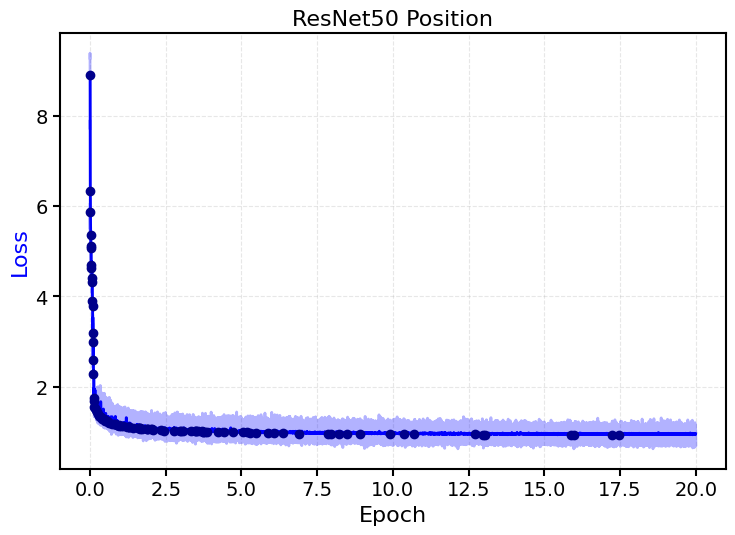

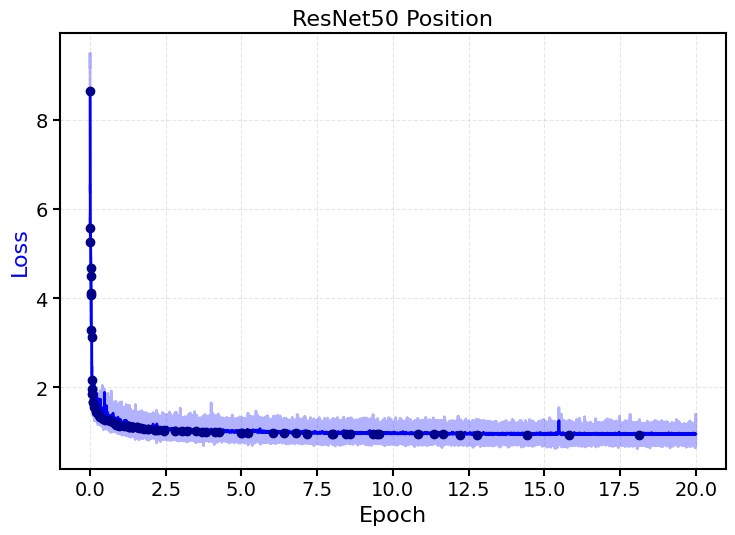

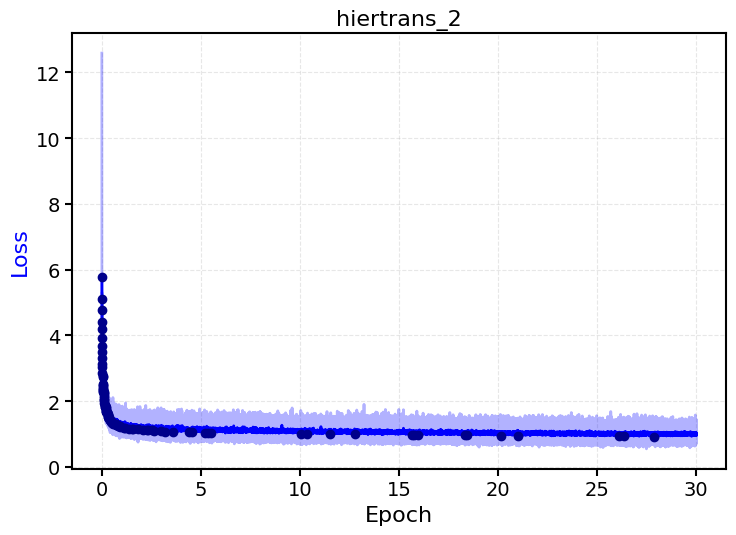

In [36]:
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
#     # ax1.set_ylim(0.1, 100)
#     # ax1.set_xlim(10,)
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# # for r in resnet_muon_energy:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
    
for r in resnet_e_position:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

# Energy and position statistics

In [37]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']
tabulate_statistics(resnet_muon_position, position_stats, position_stat_labels, position_stat_types) 

NameError: name 'resnet_muon_position' is not defined

In [38]:
tabulate_statistics(resnet_e_position, position_stats, position_stat_labels, position_stat_types)

,ResNet50 Position,ResNet50 Position,hiertrans_2
x position resolution [cm],3.46,3.40,3.78
y position resolution [cm],3.29,3.51,3.74
z position resolution [cm],3.41,3.54,3.80
3D position resolution [cm],6.42,6.64,7.23
Transverse position resolution [cm],4.65,4.78,4.64
Longitudinal position resolution [cm],3.94,4.11,5.10
Longitudinal position mean bias [cm],-0.27,-1.16,0.14


In [39]:
# energy_stats = ["momentum_fractional_errors", "momentum_residuals"]
# energy_stat_labels = ["Momentum fractional error resolution", "Momentum residual resolution"]
# energy_stat_types = ['resolution', 'resolution']

energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = [energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ['Energy percentage errors', 'Momentum percentage errors','Energy percentage error (bias)', 'Momentum percentage errors (bias)']
energy_stat_types = ['resolution', 'resolution','mean','mean']

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)


NameError: name 'resnet_muon_energy' is not defined

In [40]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet50 Energy,ResNet50 Energy,hiertrans_2
Energy percentage errors,8.73,8.69,nan
Momentum percentage errors,8.73,8.69,nan
Energy percentage error (bias),-0.54,-1.09,nan
Momentum percentage errors (bias),-0.54,-1.09,nan


In [41]:
import copy

resnet_e_energy_clipped = copy.deepcopy(resnet_e_energy)

for r in resnet_e_energy_clipped:
    pred = np.asarray(r.predictions).squeeze()
    physical_mask = pred >= 0.511
    existing = np.zeros(len(pred), dtype=bool)
    existing[r.selection] = True
    r.selection = existing & physical_mask

tabulate_statistics(resnet_e_energy_clipped, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet50 Energy,ResNet50 Energy,hiertrans_2
Energy percentage errors,8.73,8.69,8.57
Momentum percentage errors,8.73,8.69,8.57
Energy percentage error (bias),-0.54,-1.09,-2.64
Momentum percentage errors (bias),-0.54,-1.09,-2.64


0                                         below_mass: 0.0000000  nan: 0.0000  pred_min: 2.203
1                                         below_mass: 0.0000025  nan: 0.0000  pred_min: -12.025
2                                         below_mass: 0.0000101  nan: 0.0000  pred_min: 0.036


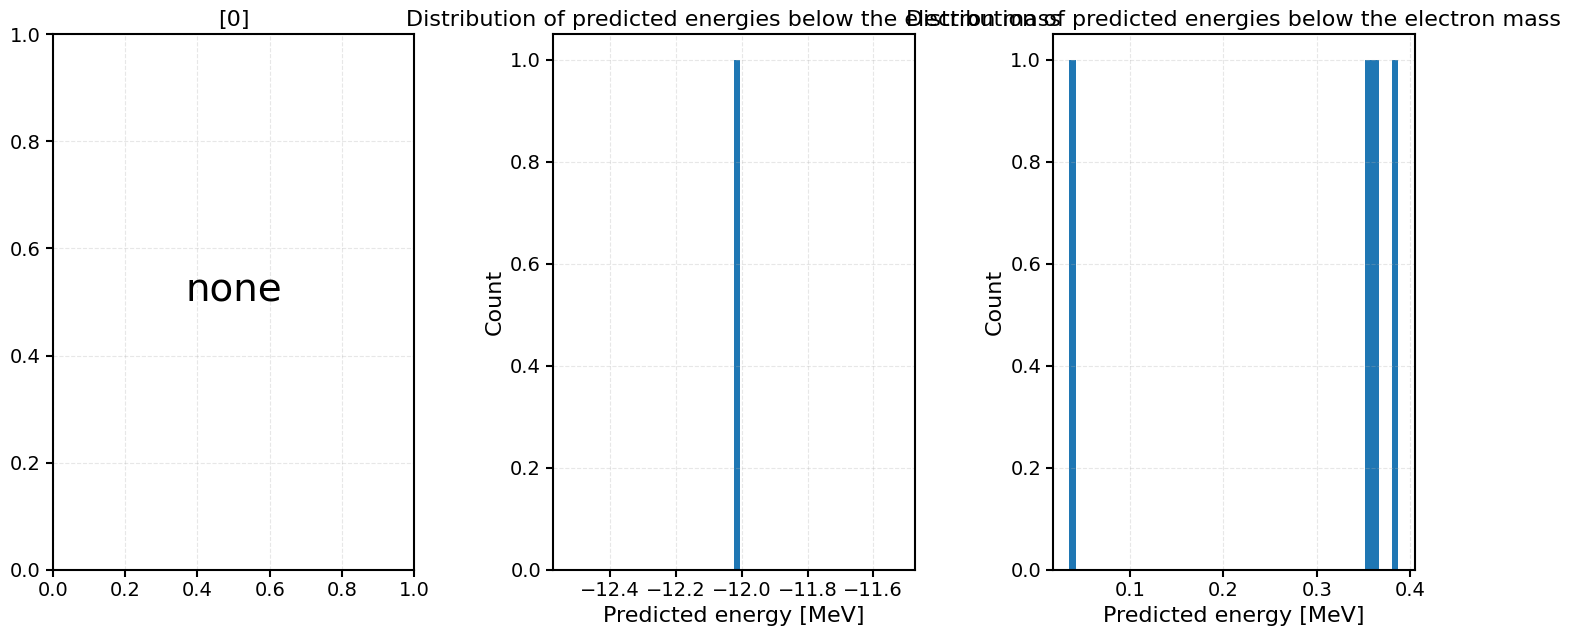

In [42]:
def nan_summary(r, name, mass=0.511):
    pred = np.asarray(r.predictions).squeeze()
    sel = r.selection
    if sel is not None:
        pred = pred[sel]
    print(f"{name:40s}  below_mass: {np.mean(pred < mass):.7f}  nan: {np.mean(~np.isfinite(pred)):.4f}  pred_min: {pred.min():.3f}")

for i, r in enumerate(resnet_e_energy):
    nan_summary(r, str(i))
    
fig, axes = plt.subplots(1, len(resnet_e_energy), figsize=(15, 7), squeeze=False)
axes = axes.flatten()

for i, (r, ax) in enumerate(zip(resnet_e_energy, axes)):
    pred = np.asarray(r.predictions).squeeze()[r.selection]
    below = pred[pred < 0.511]
    if len(below) > 0:
        ax.hist(below, bins=50)
        ax.set_xlabel("Predicted energy [MeV]")
        ax.set_ylabel("Count")
        ax.set_title('Distribution of predicted energies below the electron mass')
    else:
        ax.text(0.5, 0.5, "none", transform=ax.transAxes, ha='center')
        ax.set_title(f"[{i}]")

fig.tight_layout()
plt.show()

In [43]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)



,ResNet50 Energy,ResNet50 Energy,hiertrans_2
Energy percentage errors,8.73,8.69,nan
Momentum percentage errors,8.73,8.69,nan
Energy percentage error (bias),-0.54,-1.09,nan
Momentum percentage errors (bias),-0.54,-1.09,nan


In [44]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

,ResNet50 Energy,ResNet50 Energy,hiertrans_2
Energy percentage errors,8.73,8.69,nan
Momentum percentage errors,8.73,8.69,nan
Energy percentage error (bias),-0.54,-1.09,nan
Momentum percentage errors (bias),-0.54,-1.09,nan


In [45]:
print(test_idxs_new_geo.shape)

(2834895,)


In [46]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_direction, dir_stats, dir_stat_labels, dir_stat_types)

NameError: name 'resnet_muon_direction' is not defined

In [47]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_e_direction, dir_stats, dir_stat_labels, dir_stat_types)

,ResNet50 Direction,ResNet50 Direction,hiertrans_2
Direction residual error,3.41,3.44,4.16


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
coords = ['x', 'y', 'z']
residuals = [r.x_residuals, r.y_residuals, r.z_residuals]

r = resnet_e_position[8]  # pick whichever model, e.g. HGT

for i, (coord, res) in enumerate(zip(coords, residuals)):
    t = r.true_positions[:, i]
    p = r.position_prediction[:, i]
    res = getattr(r, f'{coord}_residuals')
    
    # scatter: predicted vs true
    axes[0, i].scatter(t, p, alpha=0.05, s=1)
    lim = [min(t.min(), p.min()), max(t.max(), p.max())]
    axes[0, i].plot(lim, lim, 'r--', lw=1)
    axes[0, i].set_xlabel(f'True {coord} [cm]')
    axes[0, i].set_ylabel(f'Predicted {coord} [cm]')
    axes[0, i].set_title(f'{coord} scatter')
    
    # residual histogram
    axes[1, i].hist(res[r.selection], bins=100, density=True, histtype='step', lw=2)
    axes[1, i].axvline(0, color='r', lw=1)
    axes[1, i].set_xlabel(f'Predicted - True {coord} [cm]')
    axes[1, i].set_title(f'{coord} residual (std={res[r.selection].std():.1f} cm)')

plt.suptitle(r.run_label)
plt.tight_layout()
plt.show()

In [ ]:
# energy investigation


# e_idx = test_idxs_new_geo[e_idxs_new_geo]
# e_mom_binning       = get_binning(data_new_geo["momentum"][e_idx], 20, 0, 1000)
# e_cos_zenith_binning = get_binning(np.cos(data_new_geo["angles"][e_idx, 0]), 20, -1, 1)
# e_azimuth_binning   = get_binning(data_new_geo["angles"][e_idx, 1] * 180 / np.pi, 20, -180, 180)
# e_dwall_binning      = get_binning(data_new_geo["dwall"][e_idx], 22, 50, 300)
# e_towall_binning     = get_binning(data_new_geo["towall"][e_idx], 30, 50, 800)

e_idx = test_idxs_new_geo[e_idxs_new_geo]
e_mom_binning        = get_binning(data_new_geo["momentum"][e_idx], 20)
e_cos_zenith_binning = get_binning(np.cos(data_new_geo["angles"][e_idx, 0]), 20)
e_azimuth_binning    = get_binning(data_new_geo["angles"][e_idx, 1] * 180 / np.pi, 20)
e_dwall_binning      = get_binning(data_new_geo["dwall"][e_idx], 22)
e_towall_binning     = get_binning(data_new_geo["towall"][e_idx], 30)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

below_mass_quantity = lambda r: (np.asarray(r.predictions).squeeze() < 0.511).astype(float)

for r in resnet_e_energy:
    plot_bias_profile([r], below_mass_quantity, e_mom_binning,    ax=axes[0], y_lim=(0,0.0002), x_label="True electron momentum [MeV]", y_label="Fraction below electron mass", legend=None)
    plot_bias_profile([r], below_mass_quantity, e_towall_binning, ax=axes[1],  y_lim=(0,0.0002), x_label="Distance to wall [cm]",        y_label="Fraction below electron mass", legend=None)
    plot_bias_profile([r], below_mass_quantity, e_dwall_binning,  ax=axes[2], y_lim=(0,0.0002), x_label="Distance from wall [cm]",      y_label="Fraction below electron mass", legend=None)
    plot_bias_profile([r], below_mass_quantity, e_cos_zenith_binning,  ax=axes[3], y_lim=(0,0.0002), x_label="Cos zenith angle",      y_label="Fraction below electron mass", legend=None)
    plot_bias_profile([r], below_mass_quantity, e_azimuth_binning,  ax=axes[4], y_lim=(0,0.0002), x_label="Azimuth angle",      y_label="Fraction below electron mass", legend=None)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

In [ ]:
for name, binning in [('mom', e_mom_binning), ('towall', e_towall_binning), ('dwall', e_dwall_binning), 
                       ('cos_zenith', e_cos_zenith_binning), ('azimuth', e_azimuth_binning)]:
    print(name, binning[0].min(), binning[0].max())

In [ ]:
# in your notebook, after you've defined the dataset
dataset = GNNMultiPMTDataset(h5file=..., geometry_file=..., k_neighbors=...)

print("shape:", dataset.mpmt_positions.shape)
print("mean per axis:", dataset.mpmt_positions.mean(axis=1))
print("std per axis:", dataset.mpmt_positions.std(axis=1))
print("min per axis:", dataset.mpmt_positions.min(axis=1))
print("max per axis:", dataset.mpmt_positions.max(axis=1))

# Energy and position plots

In [ ]:
# can add y_lim for the y axis


all_runs_pos = resnet_e_position

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning, ax=axes[0,0],y_lim=(0,18), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning, ax=axes[0,1], y_lim=(0,18),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning, ax=axes[1,0], y_lim=(0,18),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning,ax=axes[1,1],y_lim=(0,18),x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning, ax=axes[2,0],y_lim=(0,18),x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None)

In [ ]:
all_runs_mom =  resnet_e_energy #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', e_towall_binning, ax=axes[0,0], y_lim = (10,30), x_label="Distance to detector wall [cm]", y_label="Energy resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', e_dwall_binning, ax=axes[0,1],  y_lim = (10,30),x_label="Distance from detector wall [cm]",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_cos_zenith_binning, ax=axes[1,0],  y_lim = (10,30),x_label="Cosine of Zenith", y_label="Energy resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',e_azimuth_binning,ax=axes[1,1], y_lim = (10,30),x_label="Azimuth",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_mom_binning, ax=axes[2,0], y_lim = (10,30),x_label="True electron momentum [MeV]",y_label="Energy resolution",legend=None)

In [ ]:
all_runs_dir =  resnet_e_direction #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], y_lim =(3,15), x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1],  y_lim =(3,15),x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0],  y_lim =(3,15),x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1], y_lim =(3,15),x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0], y_lim =(3,15),x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)

In [ ]:
# print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
# print(len(mu_pos[mu_cuts]))

# # A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# # B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# # print(len(A), len(B))
# # print(np.array_equal(A, B))                 # identical set + order
# # print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


In [ ]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx] 


# instead of using the filtered muons list (from get quantities), im using all and then applying both the muon and the physical cuts as a selection filter (when binning) - therefore the baseline dimension is just the common events between h5 and fitqun

# resnet_muon_position = WatChMaLPositionRegression(
#     outdir_reg + output_pos,
#     "ResNet50 QT+mPMT_pos",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )


resnet_muon_direction = WatChMaLPositionRegression(
    outdir_reg + output_dir,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_mask_h5
)

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
#     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
#     true_labels=2,                        
#     indices=fq_keep_idx[mu_mask_h5],       
#     selection=None,
# )


muon_mom_binning = [
    get_binning(data_new_geo["momentum"][h5_keep_idx], 20, 0, 1000),
    get_binning(data_new_geo["momentum"][h5_keep_idx][mu_mask_h5], 20, 0, 1000),
]

muon_cos_zenith_binning = [
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0]), 20, -1, 1),
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0][mu_mask_h5]), 20, -1, 1),
]

muon_azimuth_binning = [
    get_binning(data_new_geo["angles"][h5_keep_idx, 1] * 180 / np.pi, 20, -180, 180),
    get_binning(data_new_geo["angles"][h5_keep_idx, 1][mu_mask_h5] * 180 / np.pi, 20, -180, 180),
]

muon_dwall_binning = [
    get_binning(data_new_geo["dwall"][h5_keep_idx], 22, 50, 300),
    get_binning(data_new_geo["dwall"][h5_keep_idx][mu_mask_h5], 22, 50, 300),
]

muon_towall_binning = [
    get_binning(data_new_geo["towall"][h5_keep_idx], 30, 50, 800),
    get_binning(data_new_geo["towall"][h5_keep_idx][mu_mask_h5], 30, 50, 800),
]
all_runs_pos = [resnet_muon_direction, fitqun_mu]

for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)


# fig1, ax1 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_towall_binning[r],       
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()

# handles, labels = ax1.get_legend_handles_labels()


# fig2, ax2 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()

# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()

# handles, labels = ax3.get_legend_handles_labels()


# fig4, ax4 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()

# handles, labels = ax4.get_legend_handles_labels()


# fig5, ax5 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon momentum [MeV]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)
# fig5.tight_layout()

# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()


In [ ]:

# labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# # mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
# # mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]

# resnet_muon_energy = WatChMaLEnergyRegression(
#     outdir_reg + output_energy,             
#     "ResNet50 QT+mPMT_E",
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],   
#     true_labels=labels,                                  
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )

# # fitqun_mu = FitQun1ParticleFit(
# #     fq,
# #     "fiTQun",
# #     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
# #     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
# #     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
# #     true_labels=2,
# #     indices=fq_keep_idx[mu_mask_h5],
# #     selection=None,
# # )

# all_runs_pos = [resnet_muon_energy, fitqun_mu]

# fig1, ax1 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_towall_binning[r],
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax1.set_title("Muon Energy Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()
# handles, labels = ax1.get_legend_handles_labels()

# fig2, ax2 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax2.set_title("Muon Energy Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()
# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax3.set_title("Muon Energy Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()
# handles, labels = ax3.get_legend_handles_labels()

# fig4, ax4 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax4.set_title("Muon Energy Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()
# handles, labels = ax4.get_legend_handles_labels()

# fig5, ax5 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon energy [MeV]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon Energy Resolution vs Energy", fontsize=16)
# fig5.tight_layout()
# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()